# Question 1

In [ ]:
import cv2, numpy as np
import matplotlib.pyplot as plt
import os

In [ ]:
img = cv2.imread("/content/sample_data/emma.jpg")
outdir = "q1_outputs"; os.makedirs(outdir, exist_ok=True)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

lut = np.zeros(256, np.uint8)

for r in range(0, 50):
    lut[r] = r

m1 = (255-100)/(150-50)
for r in range(50, 150):
    lut[r] = np.clip(int(round(100 + m1*(r-50))), 0, 255)

m2 = (255-160)/(255-150)
for r in range(150, 256):
    lut[r] = np.clip(int(round(160 + m2*(r-150))), 0, 255)

lut[50]  = 100
lut[150] = 160

out = cv2.LUT(gray, lut)

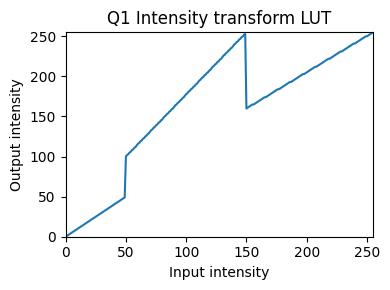

In [ ]:
plt.figure(figsize=(4,3))
plt.plot(np.arange(256), lut)
plt.title("Q1 Intensity transform LUT")
plt.xlabel("Input intensity"); plt.ylabel("Output intensity")
plt.xlim(0,255); plt.ylim(0,255)
plt.tight_layout()
plt.savefig("q1_emma_curve.png", dpi=150)
plt.show()

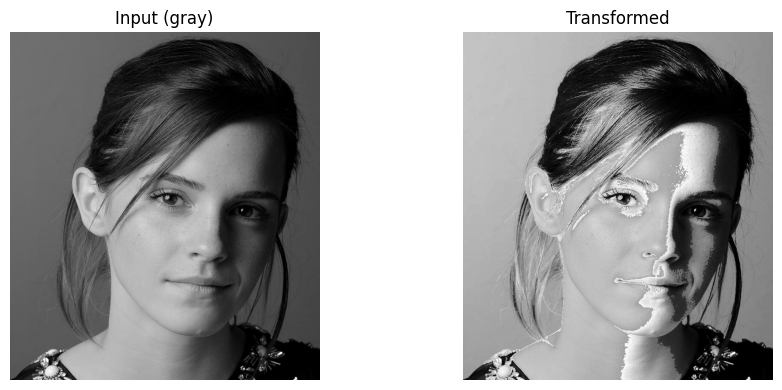

In [ ]:
cv2.imwrite(os.path.join(outdir, "q1_emma_input.png"), gray)
cv2.imwrite(os.path.join(outdir, "q1_emma_output.png"), out)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(gray, cmap="gray"); plt.title("Input (gray)"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(out, cmap="gray"); plt.title("Transformed"); plt.axis("off")
plt.tight_layout(); plt.show()

# Question 2

In [ ]:
import cv2, numpy as np, matplotlib.pyplot as plt, os

In [ ]:
img_path = "/content/sample_data/brain_proton_density_slice.png"
outdir = "q2_outputs"; os.makedirs(outdir, exist_ok=True)

img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

t, _ = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)

#a)LUT to accentuate white matter
lut_white = np.zeros(256, np.uint8)
for r in range(256):
    if r < t:
        lut_white[r] = int(0.7 * r)
    else:
        lut_white[r] = min(255, int(180 + 2.0 * (r - t)))

#b)LUT to accentuate gray matter
center = int(max(0, t - 20))
sigma = 35.0
gauss = 50 * np.exp(-0.5 * ((np.arange(256) - center) / sigma) ** 2)
lut_gray = np.clip(np.arange(256) + gauss, 0, 255).astype(np.uint8)

wm = cv2.LUT(img, lut_white)
gm = cv2.LUT(img, lut_gray)

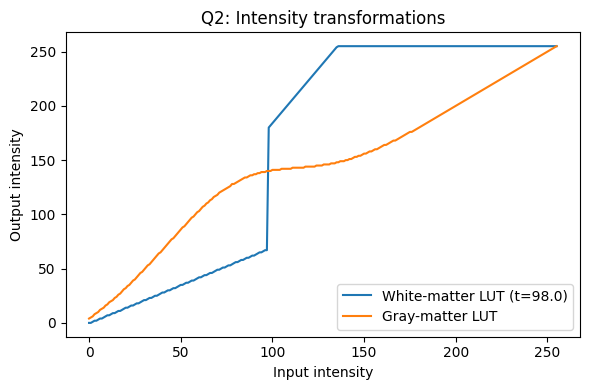

In [ ]:
#Transformation Curve
plt.figure(figsize=(6,4))
plt.plot(np.arange(256), lut_white, label=f"White-matter LUT (t={t})")
plt.plot(np.arange(256), lut_gray,  label="Gray-matter LUT")
plt.xlabel("Input intensity"); plt.ylabel("Output intensity")
plt.title("Q2: Intensity transformations")
plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(outdir, "q2_brain_luts.png"), dpi=150)
plt.show()

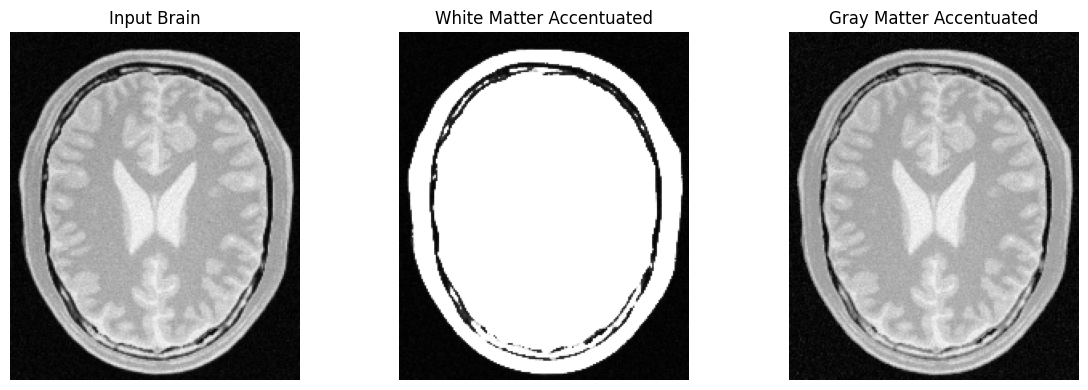

In [ ]:
cv2.imwrite(os.path.join(outdir, "q2_input_brain.png"), img)
cv2.imwrite(os.path.join(outdir, "q2_white_brain.png"), wm)
cv2.imwrite(os.path.join(outdir, "q2_gray_brain.png"),  gm)

#Input/White/Gray Brain Image comparison
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(img, cmap="gray"); plt.title("Input Brain"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(wm, cmap="gray"); plt.title("White Matter Accentuated"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(gm, cmap="gray"); plt.title("Gray Matter Accentuated"); plt.axis("off")
plt.tight_layout(); plt.show()

# Question 3

In [ ]:
import cv2, numpy as np, matplotlib.pyplot as plt

In [ ]:
img_path = "/content/sample_data/highlights_and_shadows.jpg"
outdir = "q3_outputs"; os.makedirs(outdir, exist_ok=True)

In [ ]:
bgr = cv2.imread(img_path)
lab = cv2.cvtColor(bgr, cv2.COLOR_BGR2LAB)
L, a, b = cv2.split(lab)

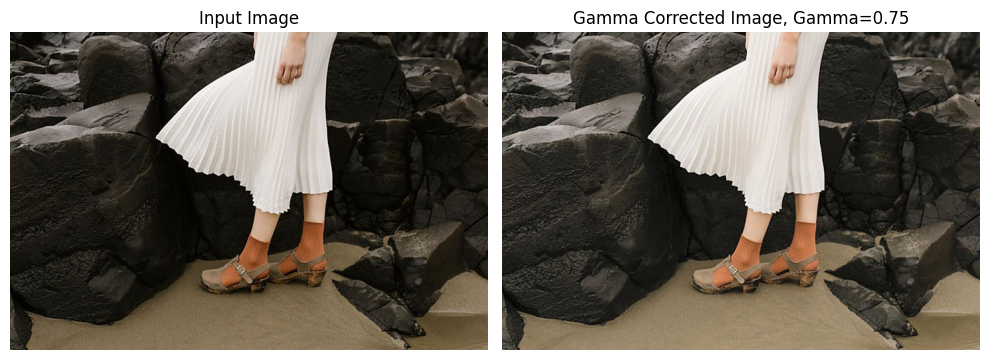

In [ ]:
#(a)Applying gamma correction
gamma = 0.75
L_norm = L.astype(np.float32) / 255.0
L_corr = np.power(L_norm, gamma)
L_corr_u8 = np.clip(L_corr * 255.0, 0, 255).astype(np.uint8)

lab_corr = cv2.merge([L_corr_u8, a, b])
bgr_corr = cv2.cvtColor(lab_corr, cv2.COLOR_LAB2BGR)

cv2.imwrite(os.path.join(outdir,"q3_input.png"), bgr)
cv2.imwrite(os.path.join(outdir,"q3_gamma075.png"), bgr_corr)

#Images of input and corrected images
plt.figure(figsize=(10,5))
plt.subplot(1,2,1); plt.imshow(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)); plt.title("Input Image"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(cv2.cvtColor(bgr_corr, cv2.COLOR_BGR2RGB)); plt.title("Gamma Corrected Image, Gamma=0.75"); plt.axis("off")
plt.tight_layout(); plt.savefig(os.path.join(outdir, "q3_image_comparison.png"), dpi=150)
plt.show()

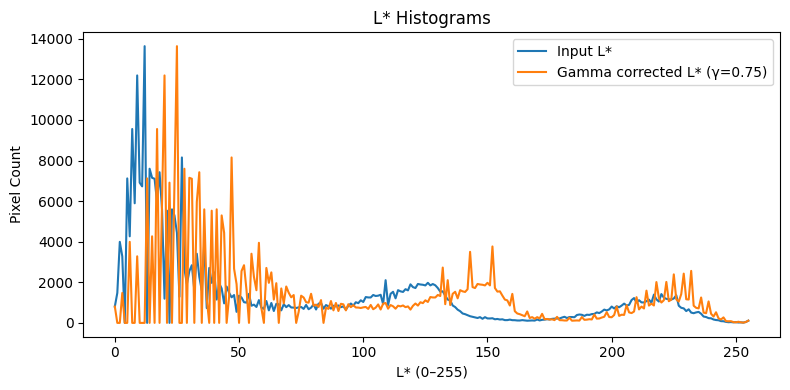

In [ ]:
#(b)Histograms of input and corrected images
hist_orig = cv2.calcHist([L],[0],None,[256],[0,256]).ravel()
hist_corr = cv2.calcHist([L_corr_u8],[0],None,[256],[0,256]).ravel()

plt.figure(figsize=(8,4))
plt.plot(hist_orig, label="Input L*")
plt.plot(hist_corr, label=f"Gamma corrected L* (γ={gamma})")
plt.title("L* Histograms")
plt.xlabel("L* (0–255)")
plt.ylabel("Pixel Count")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(outdir, "q3_histograms.png"), dpi=150)
plt.show()

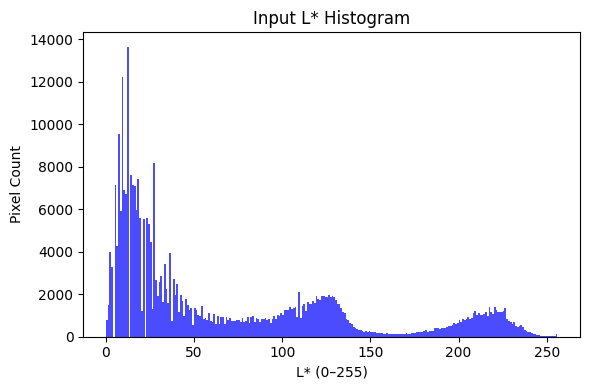

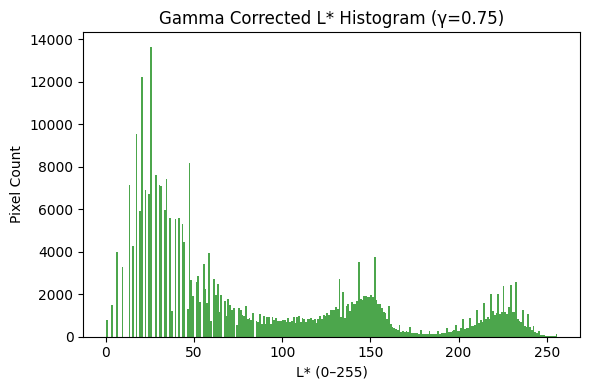

In [ ]:
#If needed to visualize in 2 histograms
#Input L*
plt.figure(figsize=(6,4))
plt.hist(L.ravel(), bins=256, range=(0,256), color="blue", alpha=0.7)
plt.title("Input L* Histogram")
plt.xlabel("L* (0–255)"); plt.ylabel("Pixel Count")
plt.tight_layout()
plt.savefig(os.path.join(outdir, "q3_hist_original.png"), dpi=150)
plt.show()

#Gamma corrected L*
plt.figure(figsize=(6,4))
plt.hist(L_corr_u8.ravel(), bins=256, range=(0,256), color="green", alpha=0.7)
plt.title(f"Gamma Corrected L* Histogram (γ={gamma})")
plt.xlabel("L* (0–255)"); plt.ylabel("Pixel Count")
plt.tight_layout()
plt.savefig(os.path.join(outdir, "q3_hist_corrected.png"), dpi=150)
plt.show()

# Question 4

In [ ]:
import cv2, numpy as np, matplotlib.pyplot as plt, os

In [ ]:
img_path = "/content/sample_data/spider.png"
outdir = "q4_outputs"; os.makedirs(outdir, exist_ok=True)

In [ ]:
bgr = cv2.imread(img_path)
hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)

def vibrance_lut(a, sigma=70.0):
    x = np.arange(256, dtype=np.float32)
    bump = a * 128.0 * np.exp(-((x - 128.0) ** 2) / (2.0 * sigma * sigma))
    return np.clip(x + bump, 0, 255).astype(np.uint8)

In [ ]:
#a)Splitting image to Hue, Saturation and Value planes
H, S, V = cv2.split(hsv)

cv2.imwrite(os.path.join(outdir, "q4_H.png"), H)
cv2.imwrite(os.path.join(outdir, "q4_S.png"), S)
cv2.imwrite(os.path.join(outdir, "q4_V.png"), V)

True

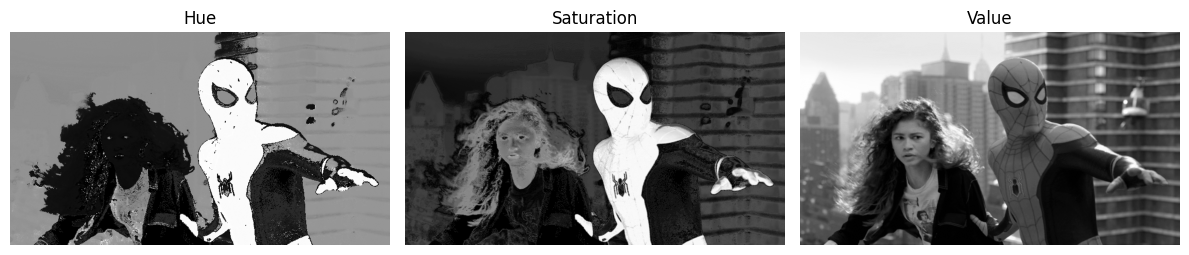

In [ ]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(H, cmap="gray"); plt.title("Hue"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(S, cmap="gray"); plt.title("Saturation"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(V, cmap="gray"); plt.title("Value"); plt.axis("off")
plt.tight_layout(); plt.show()

In [ ]:
#b)Applying the given intensity transformation to Saturation plane (S)
a = 0.70
lut = vibrance_lut(a, sigma=70.0)
S_enh = cv2.LUT(S, lut)

In [ ]:
#c)Adjusting a with couple of candidate options to pick by mean-saturation lift
candidates = [0.3, 0.5, 0.7, 0.9]
best_a, best_gain = None, -1e9
for a_try in candidates:
    lut_try = vibrance_lut(a_try)
    S_try = cv2.LUT(S, lut_try)
    gain = float(S_try.mean() - S.mean())
    if gain > best_gain:
        best_gain, best_a, S_enh, lut = gain, a_try, S_try, lut_try

print(f"Chosen a = {best_a:.2f} (mean saturation gain = {best_gain:.2f})")

Chosen a = 0.90 (mean saturation gain = 52.79)


In [ ]:
#d)Recombining all the three planes(H, S & V)
a = 0.90
lut = vibrance_lut(a, sigma=70.0)
S_enh = cv2.LUT(S, lut)

hsv_enh = cv2.merge([H, S_enh, V])
bgr_enh = cv2.cvtColor(hsv_enh, cv2.COLOR_HSV2BGR)

cv2.imwrite(os.path.join(outdir, "q4_input.png"), bgr)
cv2.imwrite(os.path.join(outdir, "q4_vibrance.png"), bgr_enh)

True

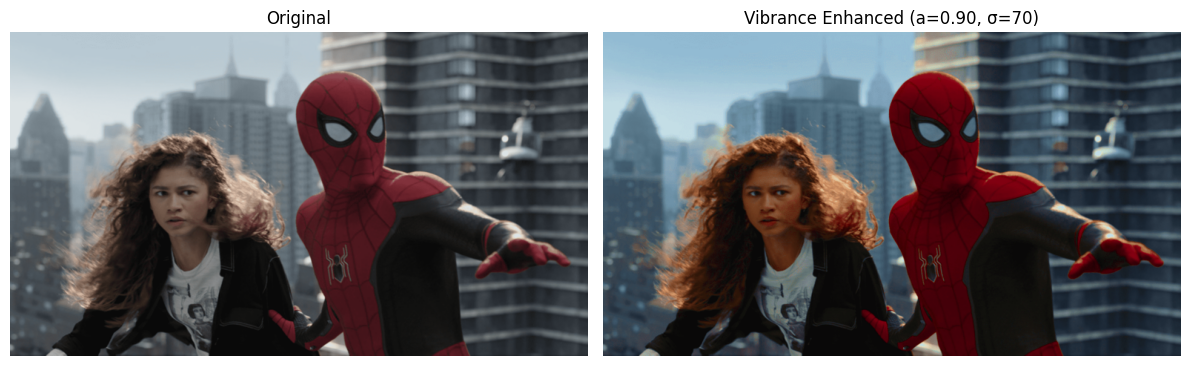

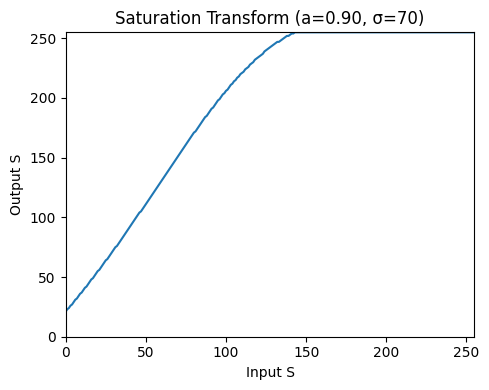

In [ ]:
#e)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1); plt.imshow(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)); plt.title("Original"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(cv2.cvtColor(bgr_enh, cv2.COLOR_BGR2RGB)); plt.title(f"Vibrance Enhanced (a={a:.2f}, σ=70)"); plt.axis("off")
plt.tight_layout(); plt.savefig(os.path.join(outdir, "q4_image_comparison.png"), dpi=150)
plt.show()

x = np.arange(256)
plt.figure(figsize=(5,4))
plt.plot(x, lut)
plt.title(f"Saturation Transform (a={a:.2f}, σ=70)")
plt.xlabel("Input S"); plt.ylabel("Output S")
plt.xlim(0,255); plt.ylim(0,255)
plt.tight_layout()
plt.savefig(os.path.join(outdir, "q4_lut_curve.png"), dpi=150)
plt.show()

# Question 5

In [ ]:
import cv2, numpy as np, matplotlib.pyplot as plt, os

In [ ]:
img_path = "/content/sample_data/jeniffer.jpg"
outdir   = "q5_outputs"; os.makedirs(outdir, exist_ok=True)

In [ ]:
bgr = cv2.imread(img_path)

In [ ]:
#a)Splitting image to Hue, Saturation and Value planes
hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
H, S, V = cv2.split(hsv)

cv2.imwrite(os.path.join(outdir, "q5_H.png"), H)
cv2.imwrite(os.path.join(outdir, "q5_S.png"), S)
cv2.imwrite(os.path.join(outdir, "q5_V.png"), V)

True

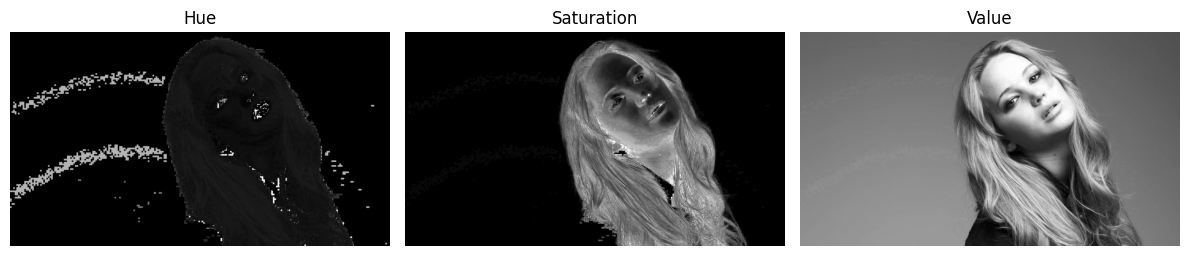

In [ ]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(H, cmap="gray"); plt.title("Hue"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(S, cmap="gray"); plt.title("Saturation"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(V, cmap="gray"); plt.title("Value"); plt.axis("off")
plt.tight_layout(); plt.show()

In [ ]:
#b)Threshold an appropriate plane to get the foreground mask
_, mask0 = cv2.threshold(V, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

kernel = np.ones((5,5), np.uint8)
mask = cv2.morphologyEx(mask0, cv2.MORPH_OPEN,  kernel, iterations=1)
mask = cv2.morphologyEx(mask,  cv2.MORPH_CLOSE, kernel, iterations=2)

num, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
if num > 1:
    largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    mask = np.uint8(labels == largest) * 255

cv2.imwrite(os.path.join(outdir, "q5_mask.png"), mask)

True

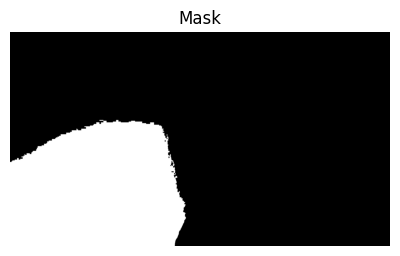

In [ ]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(mask, cmap="gray"); plt.title("Mask"); plt.axis("off")
plt.tight_layout(); plt.show()

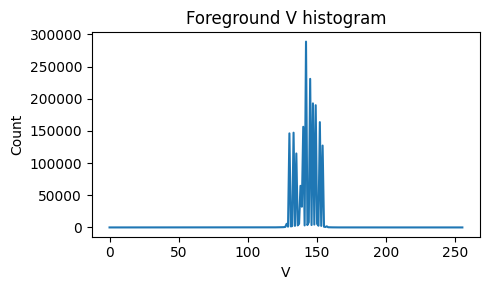

In [ ]:
#c)Extract foreground only and compute its histogram
V_fg = cv2.bitwise_and(V, V, mask=mask)
hist_fg = cv2.calcHist([V_fg], [0], mask, [256], [0,256]).ravel()

plt.figure(figsize=(5,3)); plt.plot(hist_fg); plt.title("Foreground V histogram")
plt.xlabel("V"); plt.ylabel("Count"); plt.tight_layout()
plt.savefig(os.path.join(outdir, "q5_fg_hist.png"), dpi=150); plt.show()

In [ ]:
#d)Cumulative sum of the histogram
cdf = np.cumsum(hist_fg)

cdf_masked = np.ma.masked_equal(cdf, 0)

In [ ]:
#e)Histogram-equalize the foreground
N = cdf_masked.max()
cdf_eq = (cdf_masked - cdf_masked.min()) * 255.0 / (N - cdf_masked.min())
cdf_eq = np.ma.filled(cdf_eq, 0).astype(np.uint8)

V_eq_all = cv2.LUT(V, cdf_eq)
V_fg_eq  = cv2.bitwise_and(V_eq_all, V_eq_all, mask=mask)

In [ ]:
#f)Extract the background and add with the histogram equalized foreground
bg_mask = cv2.bitwise_not(mask)
V_bg = cv2.bitwise_and(V, V, mask=bg_mask)
V_final = cv2.add(V_fg_eq, V_bg)

hsv_out = cv2.merge([H, S, V_final])
bgr_out = cv2.cvtColor(hsv_out, cv2.COLOR_HSV2BGR)

cv2.imwrite(os.path.join(outdir, "q5_input.png"), bgr)
cv2.imwrite(os.path.join(outdir, "q5_result.png"), bgr_out)

True

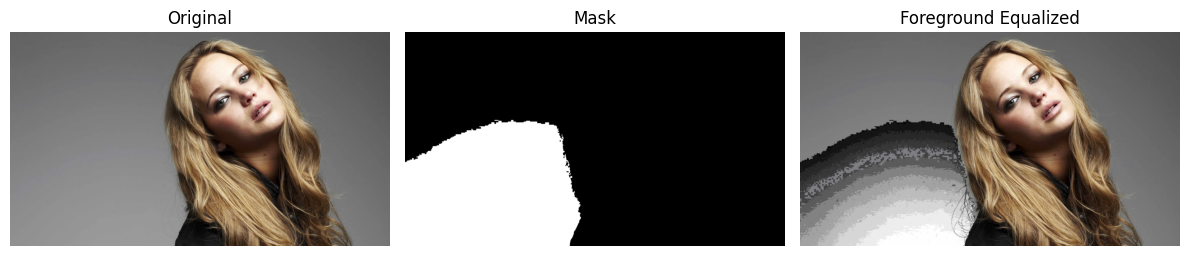

In [ ]:
plt.figure(figsize=(12,5))
plt.subplot(1,3,1); plt.imshow(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)); plt.title("Original"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(mask, cmap="gray"); plt.title("Mask"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(cv2.cvtColor(bgr_out, cv2.COLOR_BGR2RGB)); plt.title("Foreground Equalized"); plt.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(outdir, "q5_triptych.png"), dpi=150); plt.show()

# Question 6

In [ ]:
import cv2, numpy as np, matplotlib.pyplot as plt, os

In [ ]:
img_path = "/content/sample_data/einstein.png"
outdir = "q6_outputs"; os.makedirs(outdir, exist_ok=True)

img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

In [ ]:
#Sobel Kernels
Kx = np.array([[ 1, 0,-1],
               [ 2, 0,-2],
               [ 1, 0,-1]], dtype=np.float32)
Ky = Kx.T

In [ ]:
#a)Using existing filter2D to Sobel filter the image
gx_a = cv2.filter2D(img, cv2.CV_32F, Kx)
gy_a = cv2.filter2D(img, cv2.CV_32F, Ky)

mag_a = cv2.magnitude(gx_a, gy_a)
mag_a_u8 = cv2.convertScaleAbs(mag_a)

cv2.imwrite(os.path.join(outdir, "q6a_gx.png"), cv2.convertScaleAbs(gx_a))
cv2.imwrite(os.path.join(outdir, "q6a_gy.png"), cv2.convertScaleAbs(gy_a))
cv2.imwrite(os.path.join(outdir, "q6a_mag.png"), mag_a_u8)

True

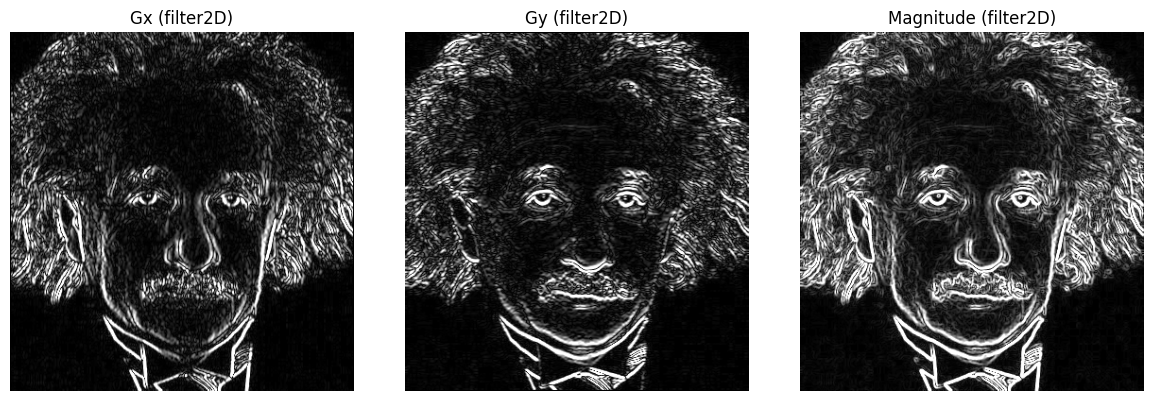

In [ ]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(cv2.convertScaleAbs(gx_a), cmap="gray"); plt.title("Gx (filter2D)"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(cv2.convertScaleAbs(gy_a), cmap="gray"); plt.title("Gy (filter2D)"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(mag_a_u8, cmap="gray"); plt.title("Magnitude (filter2D)"); plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
#b)Code for Sobel filtering the image manually
def conv2(src, kernel):
    kh, kw = kernel.shape
    ph, pw = kh//2, kw//2
    src_p = cv2.copyMakeBorder(src, ph, ph, pw, pw, cv2.BORDER_REFLECT)
    out = np.zeros_like(src, dtype=np.float32)
    k = np.flipud(np.fliplr(kernel)).astype(np.float32)
    for y in range(out.shape[0]):
        for x in range(out.shape[1]):
            roi = src_p[y:y+kh, x:x+kw].astype(np.float32)
            out[y, x] = np.sum(roi * k)
    return out

gx_b = conv2(img, Kx)
gy_b = conv2(img, Ky)
mag_b = cv2.magnitude(gx_b, gy_b)
mag_b_u8 = cv2.convertScaleAbs(mag_b)

cv2.imwrite(os.path.join(outdir, "q6b_mag_manual.png"), mag_b_u8)

True

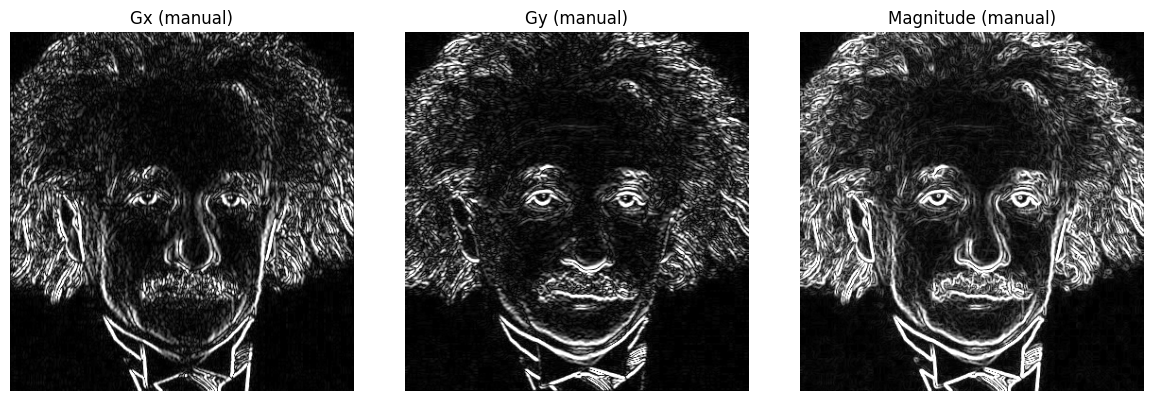

In [ ]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(cv2.convertScaleAbs(gx_b), cmap="gray"); plt.title("Gx (manual)"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(cv2.convertScaleAbs(gy_b), cmap="gray"); plt.title("Gy (manual)"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(mag_b_u8, cmap="gray"); plt.title("Magnitude (manual)"); plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
#c)Sobel using separability
col = np.array([[1],[2],[1]], dtype=np.float32)
row = np.array([[1,0,-1]], dtype=np.float32)

gx_c = cv2.sepFilter2D(img, cv2.CV_32F, row, col)
gy_c = cv2.sepFilter2D(img, cv2.CV_32F, col, row)

mag_c = cv2.magnitude(gx_c, gy_c)
mag_c_u8 = cv2.convertScaleAbs(mag_c)

cv2.imwrite(os.path.join(outdir, "q6c_mag_separable.png"), mag_c_u8)

True

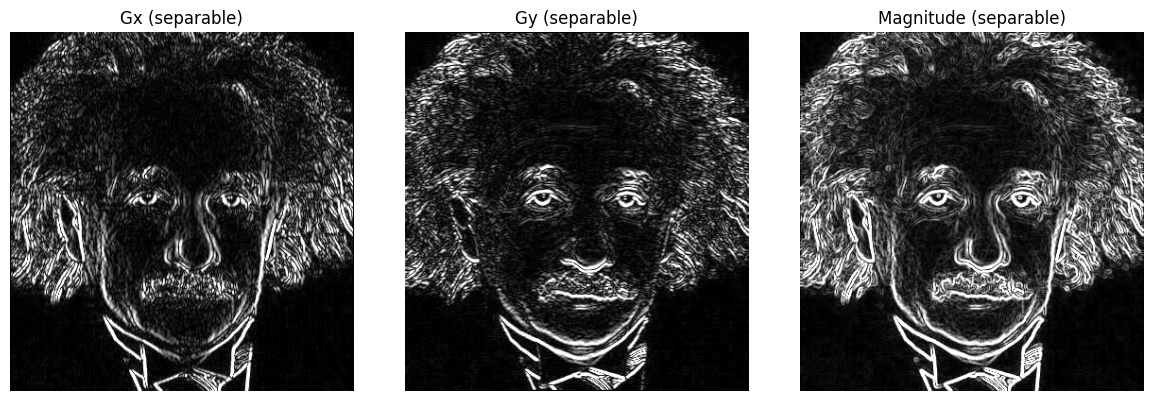

In [ ]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(cv2.convertScaleAbs(gx_c), cmap="gray"); plt.title("Gx (separable)"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(cv2.convertScaleAbs(gy_c), cmap="gray"); plt.title("Gy (separable)"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(mag_c_u8, cmap="gray"); plt.title("Magnitude (separable)"); plt.axis("off")
plt.tight_layout()
plt.show()

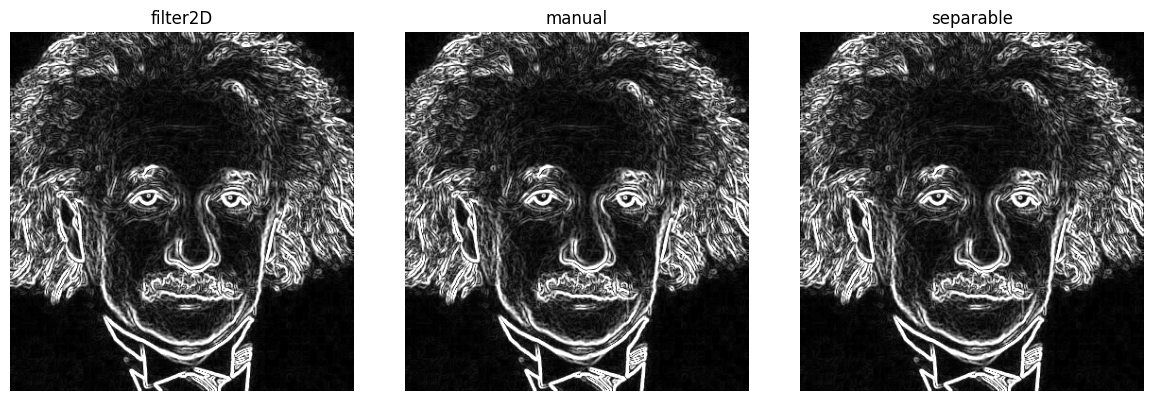

In [ ]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(mag_a_u8, cmap="gray"); plt.title("filter2D");   plt.axis("off")
plt.subplot(1,3,2); plt.imshow(mag_b_u8, cmap="gray"); plt.title("manual");     plt.axis("off")
plt.subplot(1,3,3); plt.imshow(mag_c_u8, cmap="gray"); plt.title("separable");  plt.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(outdir, "q6_comparison.png"), dpi=150)
plt.show()

# Question 7

In [ ]:
import os, cv2, numpy as np, matplotlib.pyplot as plt

In [ ]:
def zoom(img, s, method="nearest"):
    """
    Upsample by factor s using nearest or bilinear.
    Supports grayscale (H,W) and color (H,W,C).
    """
    if img is None:
        raise ValueError("zoom(): input image is None")

    is_gray = (img.ndim == 2)
    if is_gray:
        img = img[..., None]

    H, W, C = img.shape
    H2, W2 = int(round(H * s)), int(round(W * s))

    ys = (np.arange(H2) + 0.5) / s - 0.5
    xs = (np.arange(W2) + 0.5) / s - 0.5

    ys = np.clip(ys, 0, H - 1)
    xs = np.clip(xs, 0, W - 1)

    if method == "nearest":
        yi = np.rint(ys).astype(int)
        xi = np.rint(xs).astype(int)
        out = img[yi[:, None], xi[None, :], :]

    elif method == "bilinear":
        y0 = np.floor(ys).astype(int); x0 = np.floor(xs).astype(int)
        y1 = np.clip(y0 + 1, 0, H - 1);   x1 = np.clip(x0 + 1, 0, W - 1)

        wy = (ys - y0)[:, None, None]
        wx = (xs - x0)[None, :, None]

        Ia = img[y0[:, None], x0[None, :], :]
        Ib = img[y0[:, None], x1[None, :], :]
        Ic = img[y1[:, None], x0[None, :], :]
        Id = img[y1[:, None], x1[None, :], :]

        out = (1 - wy) * ((1 - wx) * Ia + wx * Ib) + wy * ((1 - wx) * Ic + wx * Id)
    else:
        raise ValueError("method must be 'nearest' or 'bilinear'")

    out = np.clip(out, 0, 255).astype(np.uint8)
    return out[..., 0] if is_gray else out

In [ ]:
def nssd(A, B):
    if A.shape != B.shape:
        raise ValueError(f"nssd(): shape mismatch {A.shape} vs {B.shape}")
    A = A.astype(np.float32)
    B = B.astype(np.float32)
    return float(np.sum((A - B) ** 2) / (np.sum(B ** 2) + 1e-8))

In [ ]:
def show_triplet(title, small_bgr, up_near_bgr, up_bili_bgr):
    plt.figure(figsize=(12, 4))
    plt.suptitle(title)
    plt.subplot(1, 3, 1); plt.imshow(cv2.cvtColor(small_bgr, cv2.COLOR_BGR2RGB)); plt.title("Input (small)"); plt.axis("off")
    plt.subplot(1, 3, 2); plt.imshow(cv2.cvtColor(up_near_bgr, cv2.COLOR_BGR2RGB)); plt.title("×4 Nearest");     plt.axis("off")
    plt.subplot(1, 3, 3); plt.imshow(cv2.cvtColor(up_bili_bgr, cv2.COLOR_BGR2RGB)); plt.title("×4 Bilinear");    plt.axis("off")
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()

In [ ]:
pairs = [
    ("/content/sample_data/im01small.png", "/content/sample_data/im01.png"),
    ("/content/sample_data/im02small.png", "/content/sample_data/im02.png"),
    ("/content/sample_data/im03small.png", "/content/sample_data/im03.png"),
    ("/content/sample_data/taylor_small.jpg", "/content/sample_data/taylor.jpg"),
]

In [ ]:
outdir = "q7_outputs"
os.makedirs(outdir, exist_ok=True)

scale = 4.0
results = []

for small_path, big_path in pairs:
    small = cv2.imread(small_path, cv2.IMREAD_COLOR)
    big   = cv2.imread(big_path,   cv2.IMREAD_COLOR)
    if small is None or big is None:
        print(f"Skipping pair (missing file): {small_path} | {big_path}")
        continue

    up_near = zoom(small, scale, "nearest")
    up_bili = zoom(small, scale, "bilinear")

    H2, W2 = up_near.shape[:2]
    big_rs = cv2.resize(big, (W2, H2), interpolation=cv2.INTER_LINEAR)

    nn = nssd(up_near, big_rs)
    nb = nssd(up_bili, big_rs)

    base = os.path.splitext(os.path.basename(small_path))[0]
    out_near = os.path.join(outdir, f"{base}_x4_nearest.png")
    out_bili = os.path.join(outdir, f"{base}_x4_bilinear.png")
    cv2.imwrite(out_near, up_near)
    cv2.imwrite(out_bili, up_bili)

    results.append((base, nn, nb))

In [ ]:
if results:
    print("Normalized SSD (lower is better)")
    print("-" * 48)
    for name, nn, nb in results:
        print(f"{name:20s}  nearest: {nn:.6f}   bilinear: {nb:.6f}")

Normalized SSD (lower is better)
------------------------------------------------
im01small             nearest: 0.012058   bilinear: 0.010187
im02small             nearest: 0.004190   bilinear: 0.002915
im03small             nearest: 0.007210   bilinear: 0.005271
taylor_small          nearest: 0.003816   bilinear: 0.003464


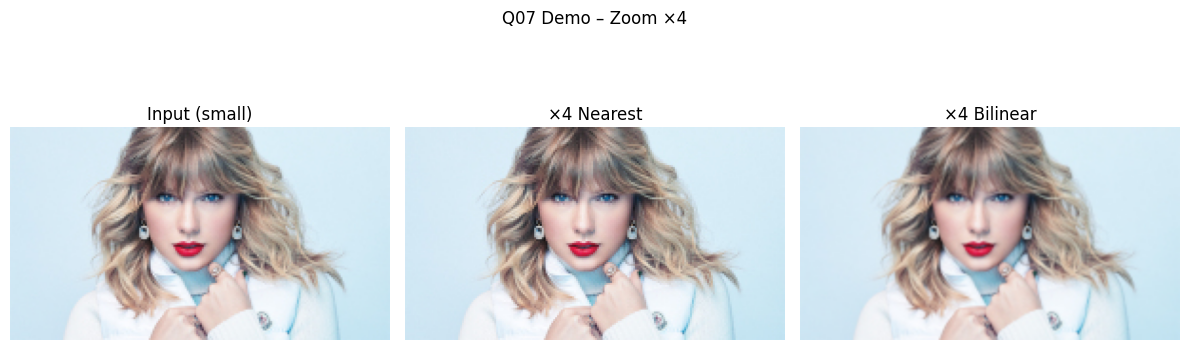

In [ ]:
demo_small = pairs[-1][0]
base = os.path.splitext(os.path.basename(demo_small))[0]
small_demo = cv2.imread(demo_small, cv2.IMREAD_COLOR)
up_near_demo = cv2.imread(os.path.join(outdir, f"{base}_x4_nearest.png"), cv2.IMREAD_COLOR)
up_bili_demo = cv2.imread(os.path.join(outdir, f"{base}_x4_bilinear.png"), cv2.IMREAD_COLOR)
if small_demo is not None and up_near_demo is not None and up_bili_demo is not None:
    show_triplet("Q07 Demo – Zoom ×4", small_demo, up_near_demo, up_bili_demo)

# Question 8

In [ ]:
import cv2, numpy as np, matplotlib.pyplot as plt, os

In [ ]:
img_path = "/content/sample_data/daisy.jpg"
outdir = "q8_outputs"; os.makedirs(outdir, exist_ok=True)

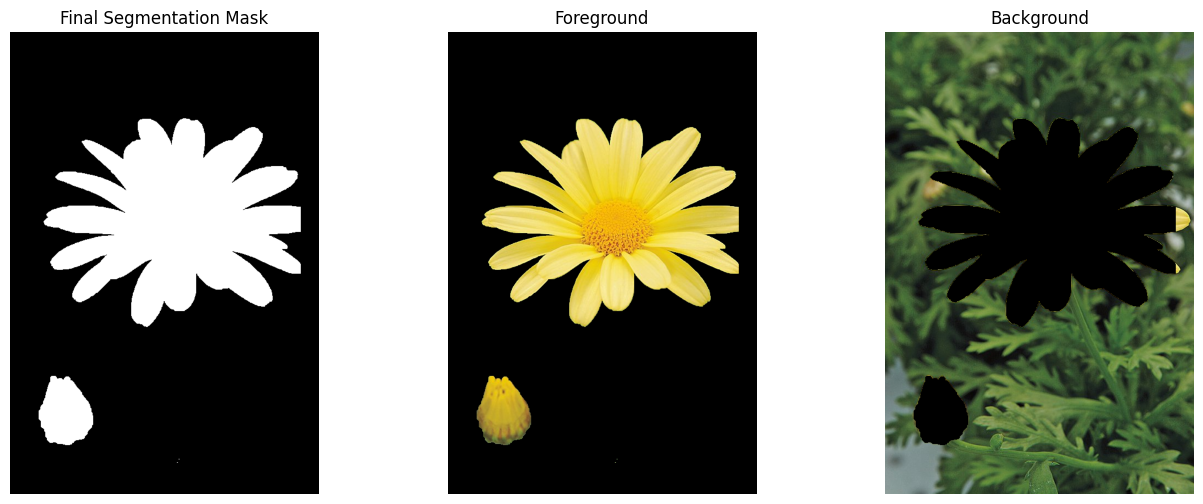

Saved to: q8_outputs/a_mask.png q8_outputs/a_foreground.png q8_outputs/a_background.png


In [ ]:
#a)GrabCut to segment
def show_row(images, titles, figsize=(16,6)):
    plt.figure(figsize=figsize)
    for i, (im, t) in enumerate(zip(images, titles), 1):
        plt.subplot(1, len(images), i)
        if im.ndim == 2:
            plt.imshow(im, cmap="gray")
        else:
            plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
        plt.axis("off"); plt.title(t)
    plt.show()

img = cv2.imread(img_path)
h, w = img.shape[:2]

mask = np.full((h, w), cv2.GC_PR_BGD, dtype=np.uint8)

hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
lower_yellow = np.array([15, 60, 90], np.uint8)
upper_yellow = np.array([40,255,255], np.uint8)
yellow = cv2.inRange(hsv, lower_yellow, upper_yellow)

kernel = np.ones((7,7), np.uint8)
yellow = cv2.morphologyEx(yellow, cv2.MORPH_CLOSE, kernel, iterations=2)
mask[yellow > 0] = cv2.GC_PR_FGD

b = int(0.06 * min(h, w))
mask[:b,:] = cv2.GC_BGD; mask[-b:,:] = cv2.GC_BGD
mask[:,:b] = cv2.GC_BGD; mask[:,-b:] = cv2.GC_BGD

bgdModel = np.zeros((1,65), np.float64)
fgdModel = np.zeros((1,65), np.float64)
cv2.grabCut(img, mask, None, bgdModel, fgdModel, 5, cv2.GC_INIT_WITH_MASK)

binary = np.where((mask==cv2.GC_FGD)|(mask==cv2.GC_PR_FGD), 1, 0).astype(np.uint8)
mask_vis = (binary*255).astype(np.uint8)
mask3 = np.repeat(binary[:,:,None], 3, axis=2)

foreground = img * mask3
background = img * (1 - mask3)

cv2.imwrite(f"{outdir}/a_mask.png", mask_vis)
cv2.imwrite(f"{outdir}/a_foreground.png", foreground)
cv2.imwrite(f"{outdir}/a_background.png", background)

show_row(
    [mask_vis, foreground, background],
    ["Final Segmentation Mask", "Foreground", "Background"]
)
print("Saved to:", f"{outdir}/a_mask.png", f"{outdir}/a_foreground.png", f"{outdir}/a_background.png")

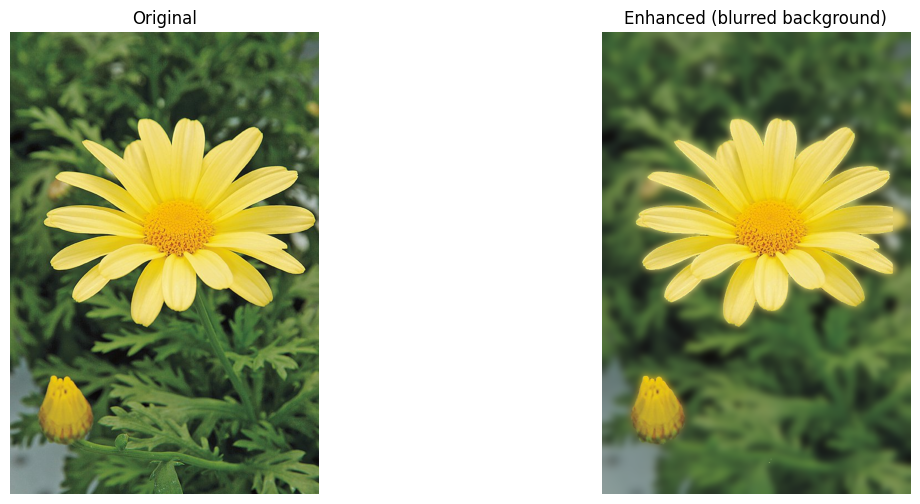

Saved to: q8_outputs/b_enhanced.png


In [ ]:
#b)Enhanced image with substantially blurred background
def show_row(images, titles, figsize=(14,6)):
    plt.figure(figsize=figsize)
    for i, (im, t) in enumerate(zip(images, titles), 1):
        plt.subplot(1, len(images), i)
        if im.ndim == 2:
            plt.imshow(im, cmap="gray")
        else:
            plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
        plt.axis("off"); plt.title(t)
    plt.show()

img = cv2.imread(img_path)
fg = cv2.imread(f"{outdir}/a_foreground.png")
mask_vis = cv2.imread(f"{outdir}/a_mask.png", 0)

if img is None or fg is None or mask_vis is None:
    raise RuntimeError("Missing inputs. Run part (a) first or fix paths.")

binary = (mask_vis > 127).astype(np.uint8)
mask3 = np.repeat(binary[:,:,None], 3, axis=2)

blurred_full = cv2.GaussianBlur(img, (41,41), 0)
enhanced = fg + blurred_full * (1 - mask3)

cv2.imwrite(f"{outdir}/b_original.png", img)
cv2.imwrite(f"{outdir}/b_enhanced.png", enhanced)

show_row([img, enhanced], ["Original", "Enhanced (blurred background)"])
print("Saved to:", f"{outdir}/b_enhanced.png")

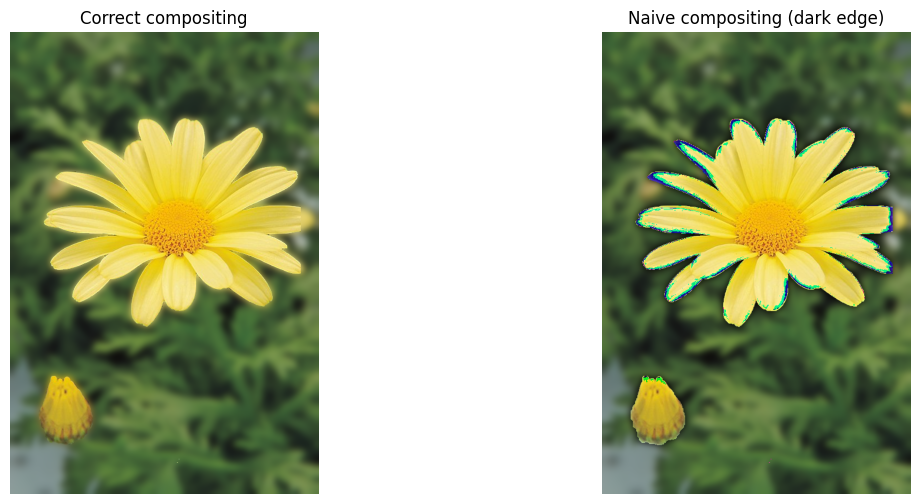

Explanation:
- In the naive pipeline, the flower region is black before blurring.
- Gaussian blur averages nearby pixels with these black values.
- This pulls down intensities just outside the mask, creating a dark halo.
- Fix: blur the FULL original image first, then composite the sharp foreground.


In [ ]:
#c)Why is the background just beyond the edge of the flower quite dark? Explanation
def show_row(images, titles, figsize=(14,6)):
    plt.figure(figsize=figsize)
    for i, (im, t) in enumerate(zip(images, titles), 1):
        plt.subplot(1, len(images), i)
        if im.ndim == 2:
            plt.imshow(im, cmap="gray")
        else:
            plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
        plt.axis("off"); plt.title(t)
    plt.show()

img = cv2.imread(img_path)
fg = cv2.imread(f"{outdir}/a_foreground.png")
bg = cv2.imread(f"{outdir}/a_background.png")
mask_vis = cv2.imread(f"{outdir}/a_mask.png", 0)

if any(x is None for x in [img, fg, bg, mask_vis]):
    raise RuntimeError("Missing inputs. Run part (a) first or fix paths.")

binary = (mask_vis > 127).astype(np.uint8)
mask3 = np.repeat(binary[:,:,None], 3, axis=2)

blurred_full = cv2.GaussianBlur(img, (41,41), 0)
correct = fg + blurred_full * (1 - mask3)

naive_bg_blurred = cv2.GaussianBlur(bg, (41,41), 0)
naive = fg + naive_bg_blurred


cv2.imwrite(f"{outdir}/c_correct.png", correct)
cv2.imwrite(f"{outdir}/c_naive.png", naive)

show_row([correct, naive], ["Correct compositing", "Naive compositing (dark edge)"])

print(
    "Explanation:\n"
    "- In the naive pipeline, the flower region is black before blurring.\n"
    "- Gaussian blur averages nearby pixels with these black values.\n"
    "- This pulls down intensities just outside the mask, creating a dark halo.\n"
    "- Fix: blur the FULL original image first, then composite the sharp foreground."
)

# Question 9

In [ ]:
import cv2, numpy as np, matplotlib.pyplot as plt, os

In [ ]:
img_path = "/content/sample_data/rice.png"
outdir = "q9_outputs"; os.makedirs(outdir, exist_ok=True)

src = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

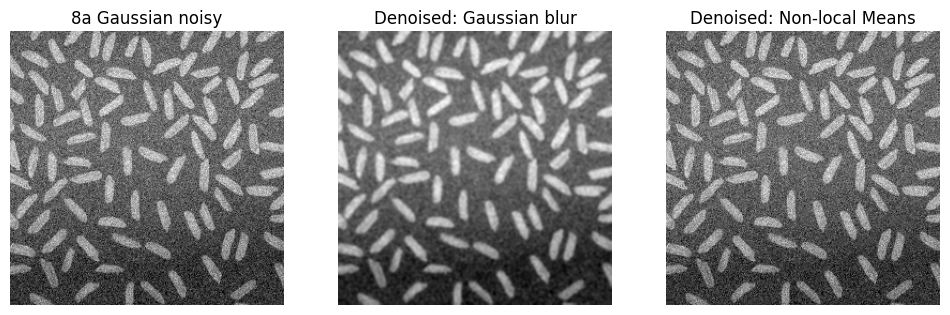

In [ ]:
#a)Preprocess image to remove noise
rng = np.random.default_rng(42)
noisy = np.clip(src.astype(np.float32)/255.0 + rng.normal(0, 0.08, src.shape), 0, 1)
noisy = (noisy*255).astype(np.uint8)
cv2.imwrite(f"{outdir}/a_gaussian_noisy.png", noisy)

den_gauss = cv2.GaussianBlur(noisy, (5,5), 0)
den_nlm   = cv2.fastNlMeansDenoising(noisy, None, h=10,
                                     templateWindowSize=7, searchWindowSize=21)

cv2.imwrite(f"{outdir}/a_gaussian_denoised_blur.png", den_gauss)
cv2.imwrite(f"{outdir}/a_gaussian_denoised_nlm.png", den_nlm)

plt.figure(figsize=(12,4))
for i,(im,title) in enumerate([(noisy,"8a Gaussian noisy"),
                               (den_gauss,"Denoised: Gaussian blur"),
                               (den_nlm,"Denoised: Non-local Means")],1):
    plt.subplot(1,3,i); plt.imshow(im, cmap="gray"); plt.axis("off"); plt.title(title)
plt.show()

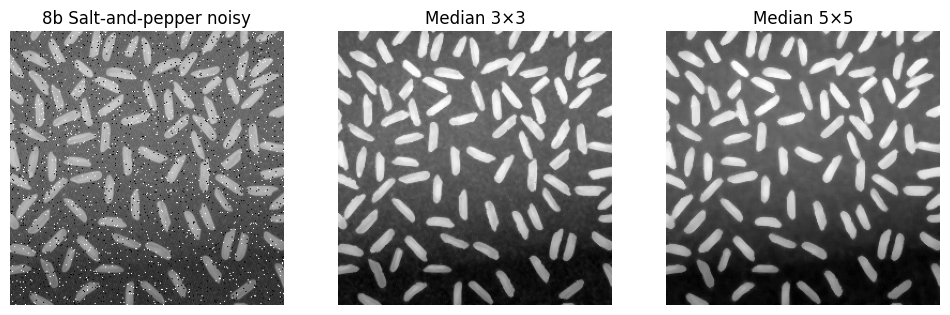

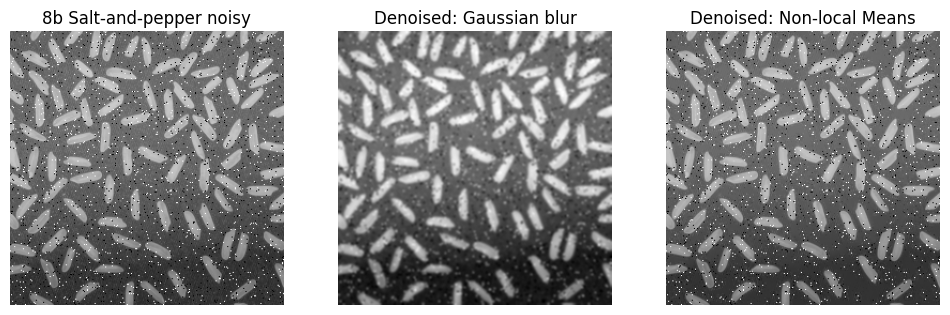

In [ ]:
#b)Preprocess to remove noise

#Generate 8b from 8aimage since it was missing
rng = np.random.default_rng(7)
p = 0.04
mask = rng.random(src.shape)
sp = src.copy()
sp[mask < p/2] = 0
sp[mask > 1 - p/2] = 255
cv2.imwrite(f"{outdir}/b_saltpepper_noisy.png", sp)

med3 = cv2.medianBlur(sp, 3)
med5 = cv2.medianBlur(sp, 5)
cv2.imwrite(f"{outdir}/b_saltpepper_denoised_med3.png", med3)
cv2.imwrite(f"{outdir}/b_saltpepper_denoised_med5.png", med5)

plt.figure(figsize=(12,4))
for i,(im,title) in enumerate([(sp,"8b Salt-and-pepper noisy"),
                               (med3,"Median 3×3"),
                               (med5,"Median 5×5")],1):
    plt.subplot(1,3,i); plt.imshow(im, cmap="gray"); plt.axis("off"); plt.title(title)
plt.show()

#remove noise
den_gauss = cv2.GaussianBlur(sp, (5,5), 0)
den_nlm   = cv2.fastNlMeansDenoising(sp, None, h=10,
                                     templateWindowSize=7, searchWindowSize=21)

cv2.imwrite(f"{outdir}/b_saltpepper_denoised_gauss.png", den_gauss)
cv2.imwrite(f"{outdir}/b_saltpepper_denoised_nlm.png", den_nlm)

plt.figure(figsize=(12,4))
for i,(im,title) in enumerate([(sp,"8b Salt-and-pepper noisy"),
                               (den_gauss,"Denoised: Gaussian blur"),
                               (den_nlm,"Denoised: Non-local Means")],1):
    plt.subplot(1,3,i); plt.imshow(im, cmap="gray"); plt.axis("off"); plt.title(title)
plt.show()

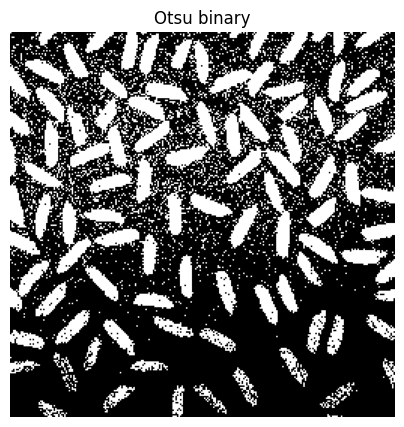

In [ ]:
#c)Apply Otsu's method to segment the image
img = cv2.imread(f"{outdir}/a_gaussian_denoised_nlm.png", cv2.IMREAD_GRAYSCALE)

_, otsu = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
cv2.imwrite(f"{outdir}/c_otsu_binary.png", otsu)

plt.figure(figsize=(5,5)); plt.imshow(otsu, cmap="gray"); plt.axis("off"); plt.title("Otsu binary")
plt.show()

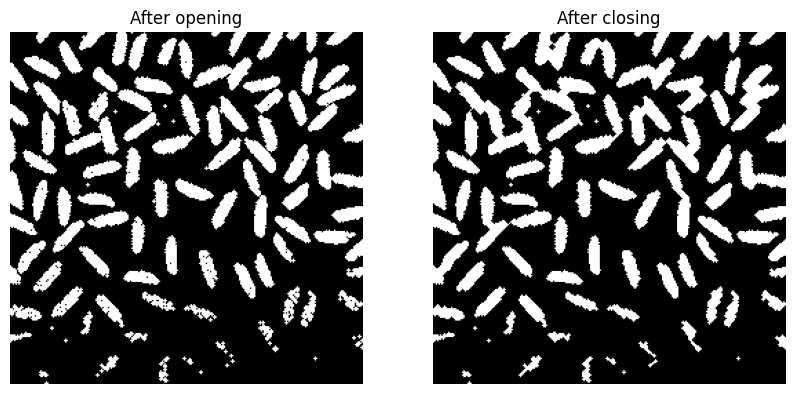

In [ ]:
#d)Morphology to remove small objects and fill holes
outdir = "q9_outputs"
otsu = cv2.imread(f"{outdir}/c_otsu_binary.png", cv2.IMREAD_GRAYSCALE)

ker = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
opened = cv2.morphologyEx(otsu, cv2.MORPH_OPEN, ker, iterations=1)
closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, ker, iterations=2)

cv2.imwrite(f"{outdir}/d_opened.png", opened)
cv2.imwrite(f"{outdir}/d_closed.png", closed)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1); plt.imshow(opened, cmap="gray"); plt.axis("off"); plt.title("After opening")
plt.subplot(1,2,2); plt.imshow(closed, cmap="gray"); plt.axis("off"); plt.title("After closing")
plt.show()

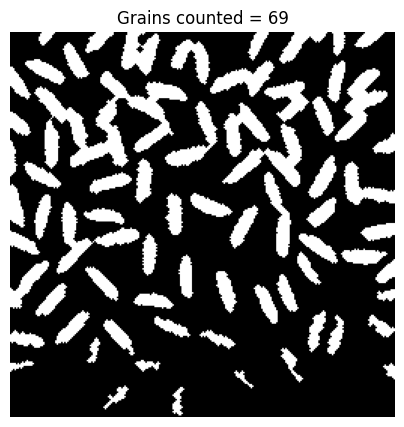

Estimated grain count: 69


In [ ]:
#e)Connect components to count rice grains
outdir = "q9_outputs"
binimg = cv2.imread(f"{outdir}/d_closed.png", cv2.IMREAD_GRAYSCALE)

num, labels, stats, _ = cv2.connectedComponentsWithStats(binimg, connectivity=8)
areas = stats[1:, cv2.CC_STAT_AREA]
keep = np.where(areas >= 40)[0] + 1
mask = np.isin(labels, keep).astype(np.uint8) * 255

num2, _, _, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
grain_count = num2 - 1

cv2.imwrite(f"{outdir}/e_components_kept.png", mask)

plt.figure(figsize=(5,5))
plt.imshow(mask, cmap="gray"); plt.axis("off"); plt.title(f"Grains counted = {grain_count}")
plt.show()

print("Estimated grain count:", grain_count)

# Question 10

In [ ]:
import os, cv2, numpy as np, matplotlib.pyplot as plt

In [ ]:
img_path = "/content/sample_data/sapphire.jpg"
outdir = "q10_outputs"; os.makedirs(outdir, exist_ok=True)

In [ ]:
def show_row(images, titles, figsize=(14,5)):
    plt.figure(figsize=figsize)
    for i,(im,t) in enumerate(zip(images,titles),1):
        plt.subplot(1,len(images),i)
        if im.ndim == 2:
            plt.imshow(im, cmap='gray')
        else:
            plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
        plt.axis('off'); plt.title(t)
    plt.show()

img_bgr = cv2.imread(img_path)
img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

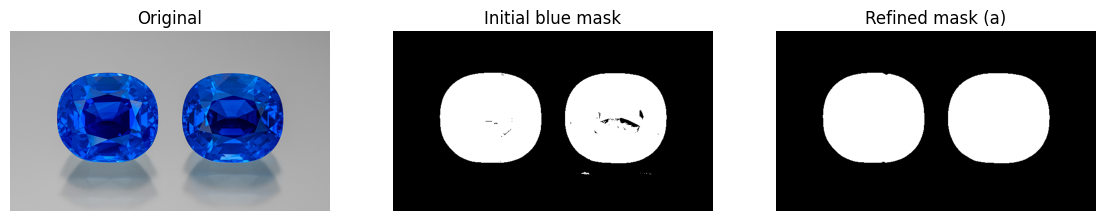

In [ ]:
#a)Segmentation algorithm to obtain a binary mask for the sapphires
hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

lower_blue1 = np.array([90, 80, 50], np.uint8)
upper_blue1 = np.array([130, 255, 255], np.uint8)
mask_blue = cv2.inRange(hsv, lower_blue1, upper_blue1)

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7,7))
mask_clean = cv2.morphologyEx(mask_blue, cv2.MORPH_OPEN, kernel, iterations=1)
mask_clean = cv2.morphologyEx(mask_clean, cv2.MORPH_CLOSE, kernel, iterations=2)

cv2.imwrite(f"{outdir}/a_mask_raw.png", mask_blue)
cv2.imwrite(f"{outdir}/a_mask_clean.png", mask_clean)

show_row([img_bgr, mask_blue, mask_clean], ["Original", "Initial blue mask", "Refined mask (a)"])

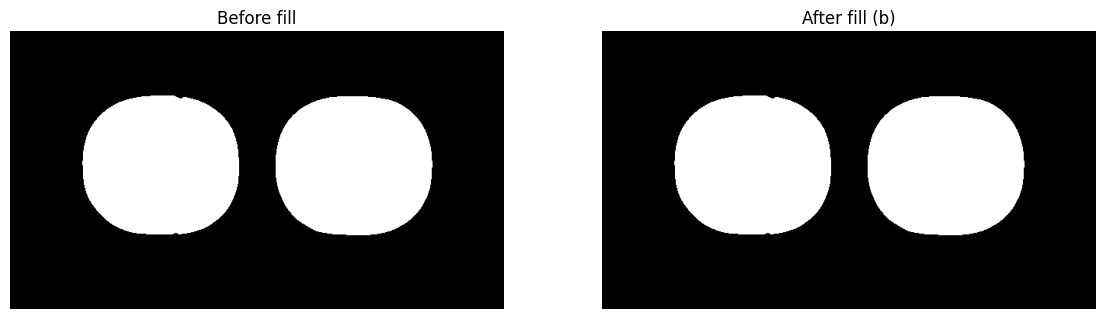

In [ ]:
#b)Morphological operation to fill the holes
mask_filled = mask_clean.copy()

contours, _ = cv2.findContours(mask_filled, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
mask_filled = np.zeros_like(mask_filled)
cv2.drawContours(mask_filled, contours, -1, 255, thickness=cv2.FILLED)

cv2.imwrite(f"{outdir}/b_mask_filled.png", mask_filled)
show_row([mask_clean, mask_filled], ["Before fill", "After fill (b)"])

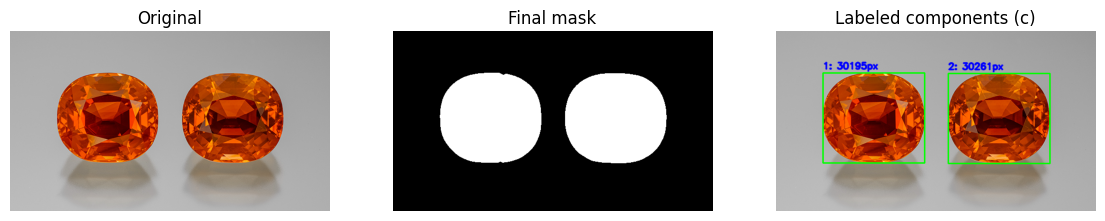

Areas in pixels for each sapphire: [30195, 30261]


In [ ]:
#c)Run connectedComponentsWithStats to obtain the areas in pixels
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask_filled, connectivity=8)

areas_px = []
bboxes = []
for label in range(1, num_labels):
    area = int(stats[label, cv2.CC_STAT_AREA])
    areas_px.append(area)
    bboxes.append(stats[label, :4])

vis = img.copy()
for i,(bb,area) in enumerate(zip(bboxes, areas_px), start=1):
    x,y,w,h = bb
    cv2.rectangle(vis, (x,y), (x+w,y+h), (0,255,0), 2)
    cv2.putText(vis, f"{i}: {area}px", (x, y-8), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,0,0), 2, cv2.LINE_AA)

cv2.imwrite(f"{outdir}/c_labeled_boxes.png", cv2.cvtColor(vis, cv2.COLOR_RGB2BGR))

show_row([img, mask_filled, vis], ["Original", "Final mask", "Labeled components (c)"])

print("Areas in pixels for each sapphire:", areas_px)

   pixel_size_µm  sapphire_1_mm²  sapphire_2_mm²
0           1.12          136.36          136.65
1           1.40          213.06          213.52
2           2.00          434.81          435.76
3           3.45         1293.83         1296.65
4           4.30         2009.90         2014.29

Assuming pixel size = 1.4 µm, areas (mm²): [213.06, 213.52]


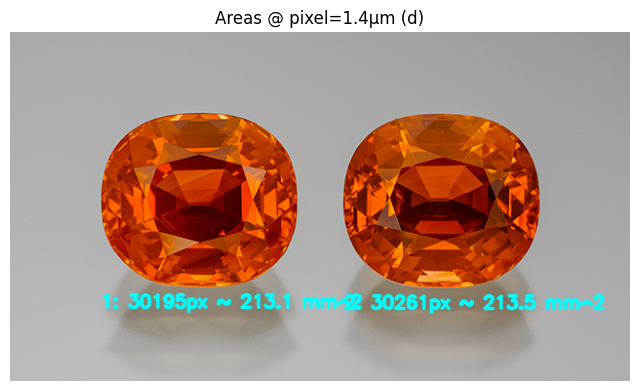

Files saved in: q10_outputs


In [ ]:
#d)If f = 8mm and the camera lens is 480mm away from the table surface
f_mm = 8.0
Z_mm = 480.0

def pixel_area_to_real_mm2(A_px, pixel_size_um):
    s_mm = pixel_size_um * 1e-3
    return ((Z_mm / f_mm)**2) * (s_mm**2) * A_px

pixel_sizes_um = [1.12, 1.4, 2.0, 3.45, 4.3]
areas_table = []
for ps in pixel_sizes_um:
    row = [ps] + [pixel_area_to_real_mm2(A, ps) for A in areas_px]
    areas_table.append(row)

import pandas as pd
df = pd.DataFrame(areas_table, columns=["pixel_size_µm"] + [f"sapphire_{i+1}_mm²" for i in range(len(areas_px))])
print(df.round(2))

df.to_csv(f"{outdir}/d_area_estimates_by_pixel_pitch.csv", index=False)

assumed_pixel_um = 1.4
areas_mm2 = [pixel_area_to_real_mm2(A, assumed_pixel_um) for A in areas_px]
print(f"\nAssuming pixel size = {assumed_pixel_um} µm, areas (mm²):", [round(a,2) for a in areas_mm2])

vis2 = img.copy()
for i,(bb,area_px,area_mm2) in enumerate(zip(bboxes, areas_px, areas_mm2), start=1):
    x,y,w,h = bb
    cv2.putText(vis2, f"{i}: {area_px}px ~ {area_mm2:.1f} mm^2", (x, y+h+20),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,0), 2, cv2.LINE_AA)

cv2.imwrite(f"{outdir}/d_area_overlay.png", cv2.cvtColor(vis2, cv2.COLOR_RGB2BGR))
show_row([vis2], [f"Areas @ pixel={assumed_pixel_um}µm (d)"], figsize=(8,5))

print("Files saved in:", outdir)